In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.ndimage.filters import gaussian_filter

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)

In [4]:
mask=(tab['proj']=='xy')

In [5]:
tab1=tab[mask]

In [6]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)

In [7]:
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)

In [8]:
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [9]:
with open(data_dir+"galaxies_tng300_072_mah_hmc.txt",'rb') as f: 
    tab_mah=pickle.load(f)

In [10]:
df = pd.read_csv(data_dir+'tng_snap.csv')
age_tab=np.asarray(df['age'])
z_tab=np.asarray(df['redshift'])

In [11]:
age_tab[25]

2.145

In [12]:
z_tab[[33,50,59,72]]

array([2. , 1. , 0.7, 0.4])

In [13]:
age_tab[[33,50,59,72]]

array([3.285, 5.878, 7.314, 9.389])

In [15]:
mpeak_hist=[[],]
for gal_num in range(3388):
    if (len(tab_mah[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_mah[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['mass_halo'][gal_num]],tab_mah[gal_num][1]*1e10/0.6774))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        print(gal_num)
        xdata0=[None]
        ydata0=[None]
    mpeak_hist.append([xdata0,ydata0])
del mpeak_hist[0]

1036
1758
2015
2085
2245
3025
3243


In [16]:
def stack_mah(gal_num_list):
    prof_curve=[]
    median=[]
    upper=[]
    lower=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            x=age_tab[mpeak_hist[gal_num][0]]
            y=np.asarray(mpeak_hist[gal_num][1])
            mask00=(x>1)
            if np.min(x[mask00])<3:
                f=interp1d(x[mask00],y[mask00]/y[mask00][-1],kind='cubic')
                prof_curve.append(f(age_list))
        for i in range(len(age_list)):
            median.append(np.median(np.asarray(prof_curve).T[i]))
            upper.append(np.percentile(np.asarray(prof_curve).T[i],84))
            lower.append(np.percentile(np.asarray(prof_curve).T[i],16))
    return median,upper,lower

In [17]:
age_list=age_tab[32:73]*0.9999

Text(0, 0.5, '$M_{\\rm peak}/M_{{\\rm peak},z=0.4}$')

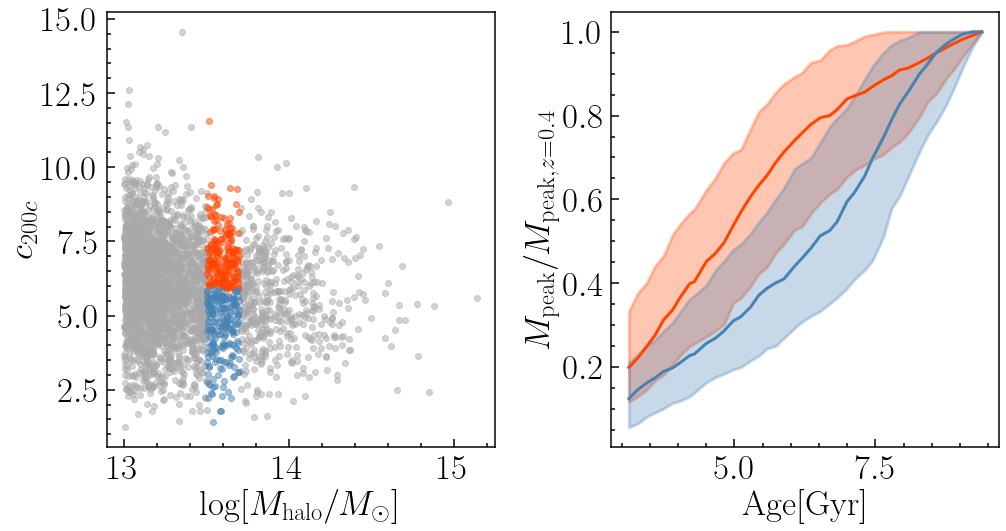

In [18]:
mask_up=(tab2['c_200c']>5.9)&(tab2['c_200c']<15)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_down=(tab2['c_200c']<5.9)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_x=(tab2['c_200c']<15)
fig=plt.figure(figsize=(16,8))
gs = fig.add_gridspec(1,2, hspace=0, wspace=0.3)
(ax1,ax2)= gs.subplots()
gal_num_list_up=tab2[mask_up]['gal_num']
gal_num_list_down=tab2[mask_down]['gal_num']
ax1.scatter(np.log10(tab2[mask_x&(~mask_down)&(~mask_up)]['mass_halo']),tab2[mask_x&(~mask_down)&(~mask_up)]['c_200c'],c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_up]['mass_halo']),tab2[mask_up]['c_200c'],c='orangered',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_down]['mass_halo']),tab2[mask_down]['c_200c'],c='steelblue',alpha=0.5)
ax1.set_xlabel(r'$\log[M_{\rm halo}/M_\odot]$')
ax1.set_ylabel(r'$c_{200c}$')
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')

Text(0, 0.5, '$M_{\\rm peak}/M_{{\\rm peak},z=0.4}$')

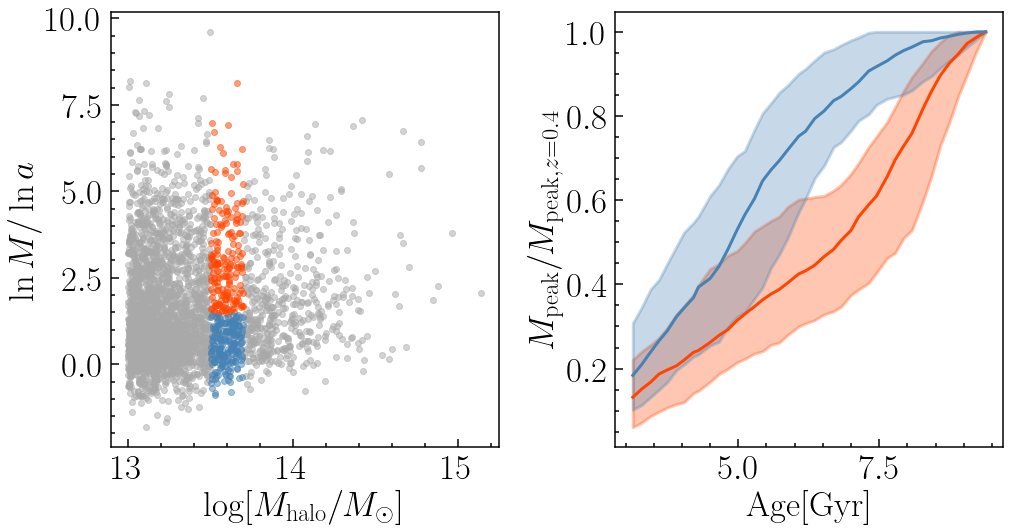

In [20]:
mask_up=(tab2['acc_rate']>1.43)&(tab2['c_200c']<15)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_down=(tab2['acc_rate']<1.43)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_x=(tab2['acc_rate']<15)
fig=plt.figure(figsize=(16,8))
gs = fig.add_gridspec(1,2, hspace=0, wspace=0.3)
(ax1,ax2)= gs.subplots()
gal_num_list_up=tab2[mask_up]['gal_num']
gal_num_list_down=tab2[mask_down]['gal_num']
ax1.scatter(np.log10(tab2[mask_x&(~mask_down)&(~mask_up)]['mass_halo']),tab2[mask_x&(~mask_down)&(~mask_up)]['acc_rate'],c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_up]['mass_halo']),tab2[mask_up]['acc_rate'],c='orangered',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_down]['mass_halo']),tab2[mask_down]['acc_rate'],c='steelblue',alpha=0.5)
ax1.set_xlabel(r'$\log[M_{\rm halo}/M_\odot]$')
ax1.set_ylabel(r'$\ln M/\ln a$')
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')

In [28]:
mask_x=(tab2['acc_rate']<15)
np.percentile(tab2['acc_rate'][mask_x],2/3*100)

1.962306223691502

Text(0, 0.5, '$M_{\\rm peak}/M_{{\\rm peak},z=0.4}$')

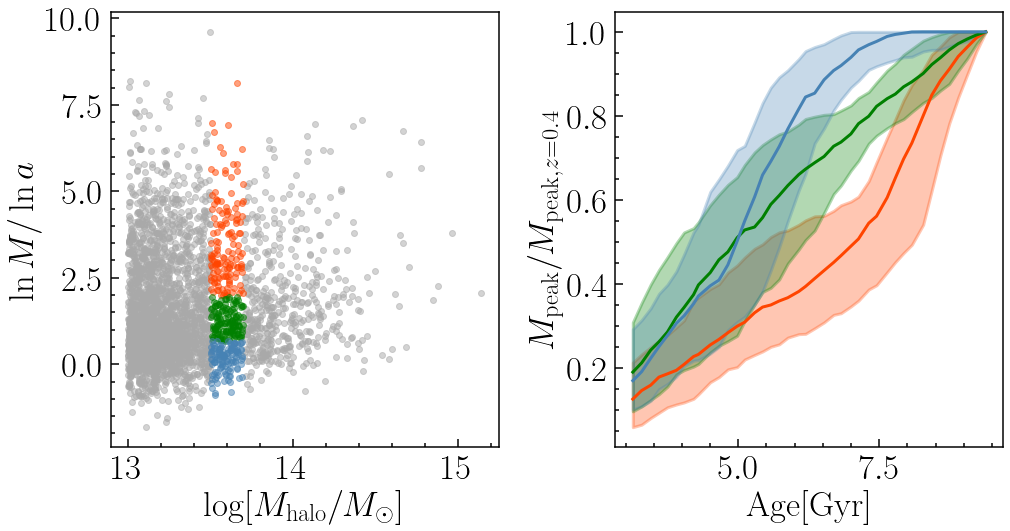

In [30]:
mask_up=(tab2['acc_rate']>1.962)&(tab2['c_200c']<15)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_down=(tab2['acc_rate']<0.6785)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_mid=(tab2['acc_rate']>0.6785)&(tab2['acc_rate']<1.962)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_x=(tab2['acc_rate']<15)
fig=plt.figure(figsize=(16,8))
gs = fig.add_gridspec(1,2, hspace=0, wspace=0.3)
(ax1,ax2)= gs.subplots()
gal_num_list_up=tab2[mask_up]['gal_num']
gal_num_list_mid=tab2[mask_mid]['gal_num']
gal_num_list_down=tab2[mask_down]['gal_num']
ax1.scatter(np.log10(tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['mass_halo']),tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['acc_rate'],c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_up]['mass_halo']),tab2[mask_up]['acc_rate'],c='orangered',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_mid]['mass_halo']),tab2[mask_mid]['acc_rate'],c='green',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_down]['mass_halo']),tab2[mask_down]['acc_rate'],c='steelblue',alpha=0.5)
ax1.set_xlabel(r'$\log[M_{\rm halo}/M_\odot]$')
ax1.set_ylabel(r'$\ln M/\ln a$')
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_mid)
ax2.plot(age_list,median,color='green',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='green',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')

In [32]:
mask_x=(tab2['c_200c']<15)
np.percentile(tab2['c_200c'][mask_x],1/3*100)

5.260737821885846

Text(0, 0.5, '$M_{\\rm peak}/M_{{\\rm peak},z=0.4}$')

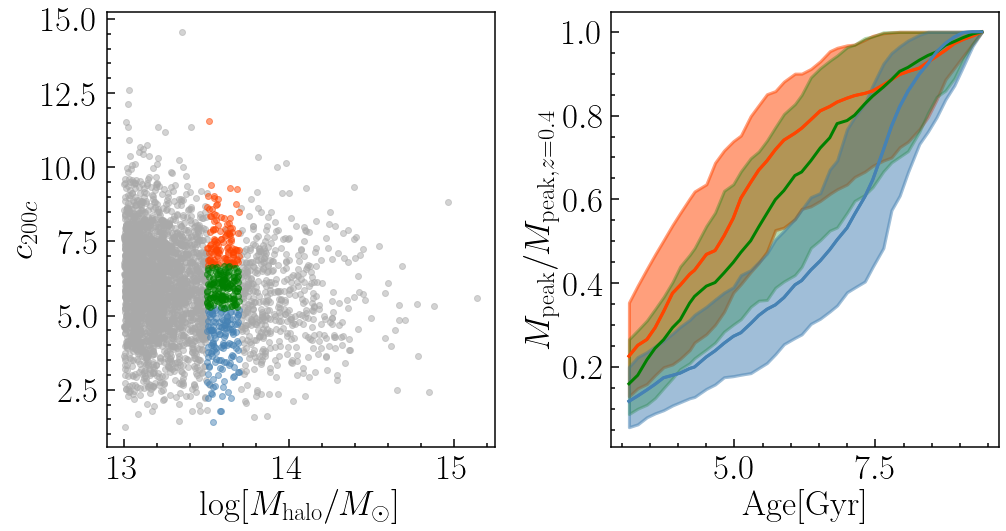

In [33]:
mask_up=(tab2['c_200c']>6.67)&(tab2['c_200c']<15)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_mid=(tab2['c_200c']<6.67)&(tab2['c_200c']>5.26)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_down=(tab2['c_200c']<5.26)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_x=(tab2['c_200c']<15)
fig=plt.figure(figsize=(16,8))
gs = fig.add_gridspec(1,2, hspace=0, wspace=0.3)
(ax1,ax2)= gs.subplots()
gal_num_list_up=tab2[mask_up]['gal_num']
gal_num_list_mid=tab2[mask_mid]['gal_num']
gal_num_list_down=tab2[mask_down]['gal_num']
ax1.scatter(np.log10(tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['mass_halo']),tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['c_200c'],c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_up]['mass_halo']),tab2[mask_up]['c_200c'],c='orangered',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_down]['mass_halo']),tab2[mask_down]['c_200c'],c='steelblue',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_mid]['mass_halo']),tab2[mask_mid]['c_200c'],c='green',alpha=0.5)
ax1.set_xlabel(r'$\log[M_{\rm halo}/M_\odot]$')
ax1.set_ylabel(r'$c_{200c}$')
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_mid)
ax2.plot(age_list,median,color='green',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='green',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')

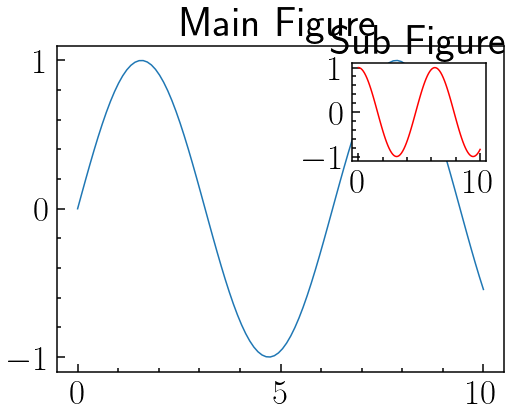

In [34]:
import matplotlib.pyplot as plt

import numpy as np

# Create sample data
x = np.linspace(0, 10, 100)
y_main = np.sin(x)
y_sub = np.cos(x)

# Create the main figure and axes
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, y_main, label='Main plot')
ax.set_title('Main Figure')

# Create an inset of the main axes
# The parameters are [left, bottom, width, height] as a fraction of the figure width and height
ax_sub = inset_axes(ax, width="30%", height="30%", loc='upper right')

# Plot on the inset axes
ax_sub.plot(x, y_sub, label='Sub plot', color='r')
ax_sub.set_title('Sub Figure')

plt.show()


Text(0.5, 0, '$z$')

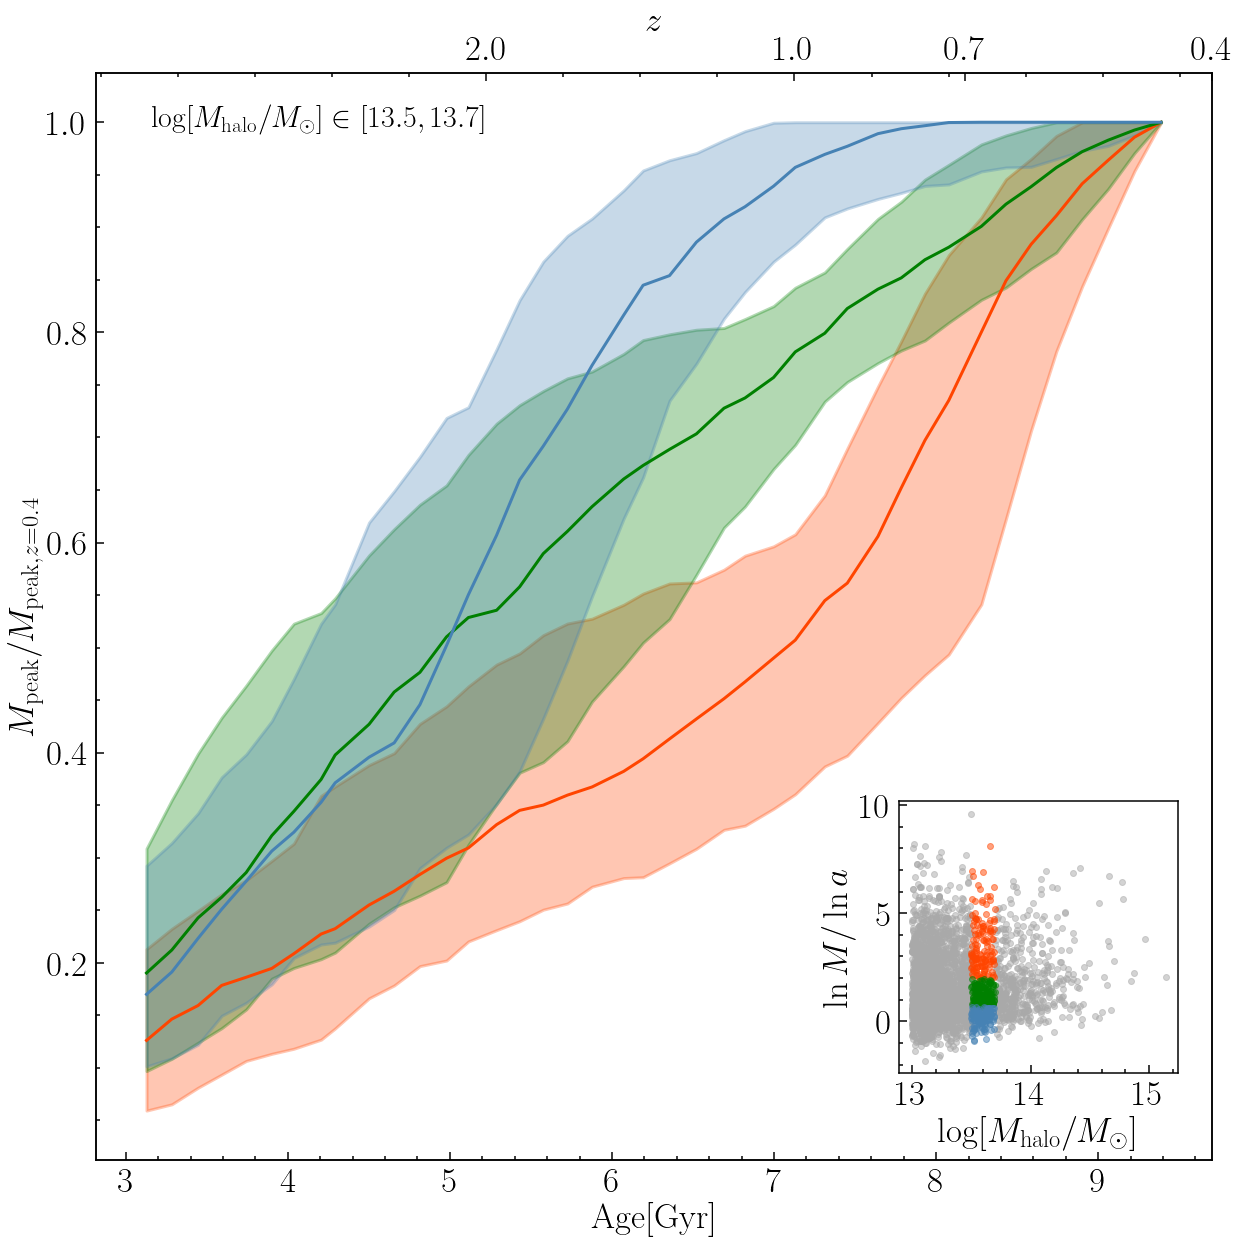

In [89]:
mask_up=(tab2['acc_rate']>1.962)&(tab2['c_200c']<15)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_down=(tab2['acc_rate']<0.6785)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_mid=(tab2['acc_rate']>0.6785)&(tab2['acc_rate']<1.962)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_x=(tab2['acc_rate']<15)
fig, ax2 = plt.subplots(figsize=(20, 20))
ax1 = ax2.inset_axes([0.72, 0.08, 0.25,0.25], transform=ax2.transAxes)
gal_num_list_up=tab2[mask_up]['gal_num']
gal_num_list_mid=tab2[mask_mid]['gal_num']
gal_num_list_down=tab2[mask_down]['gal_num']
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_mid)
ax2.plot(age_list,median,color='green',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='green',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')
ax1.scatter(np.log10(tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['mass_halo']),tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['acc_rate'],c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_up]['mass_halo']),tab2[mask_up]['acc_rate'],c='orangered',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_mid]['mass_halo']),tab2[mask_mid]['acc_rate'],c='green',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_down]['mass_halo']),tab2[mask_down]['acc_rate'],c='steelblue',alpha=0.5)
ax1.set_xlabel(r'$\log[M_{\rm halo}/M_\odot]$')
ax1.set_ylabel(r'$\ln M/\ln a$')
ax2.text(0.05,0.95,r'$\log[M_{\rm halo}/M_\odot]\in[13.5,13.7]$',fontsize=30,transform=ax2.transAxes)
ax3=ax2.twiny()
ax3.set_xticks(age_tab[[33,50,59,72]],[r'$2.0$',r'$1.0$',r'$0.7$',r'$0.4$'])
ax3.set_xlabel(r'$z$')

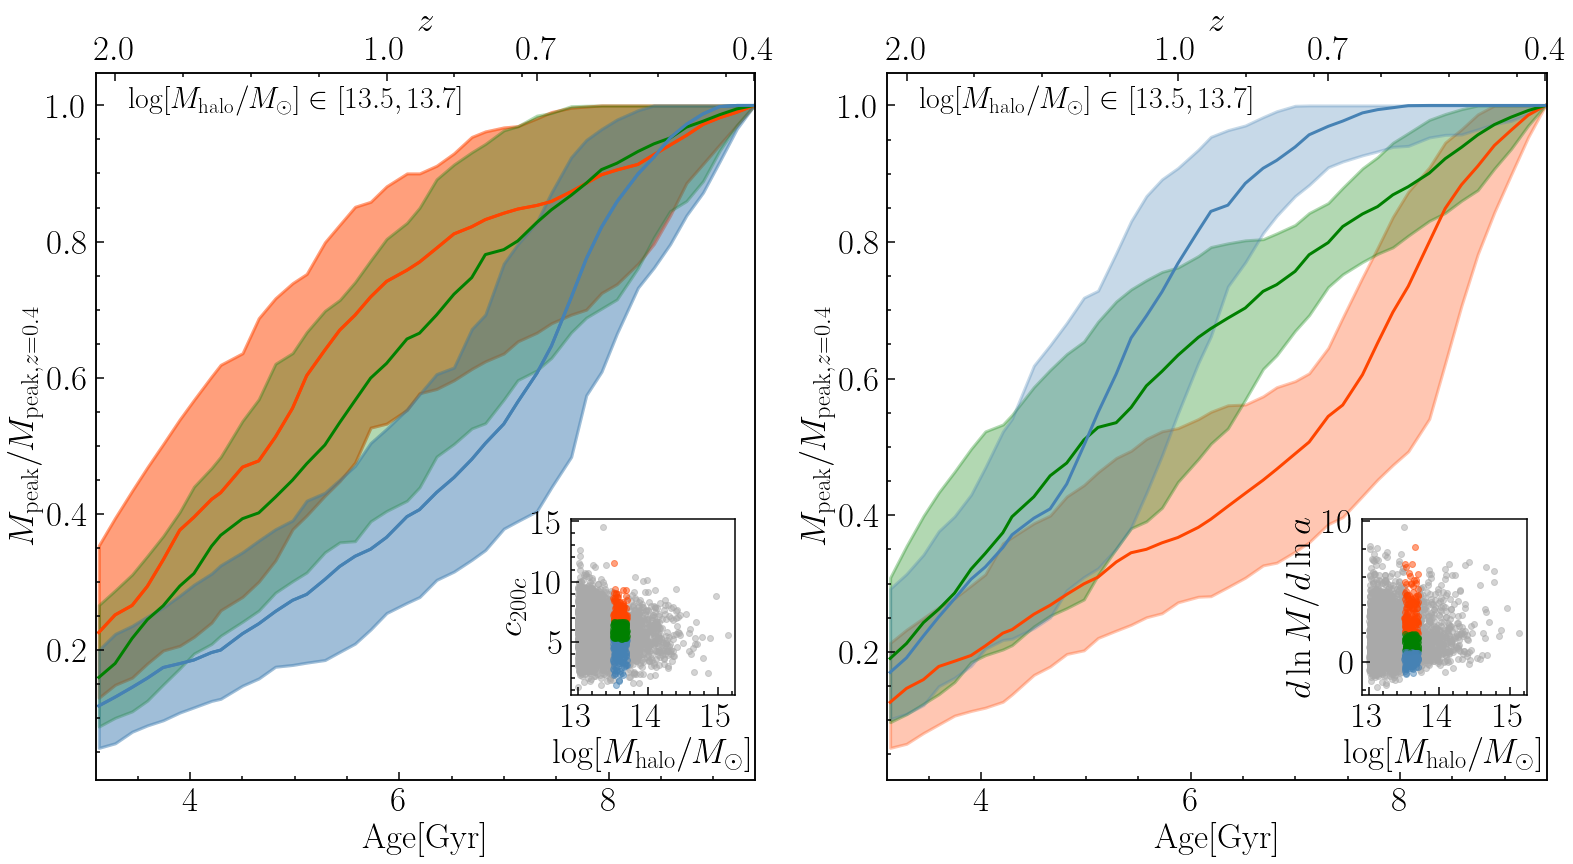

In [40]:
mask_up=(tab2['c_200c']>6.67)&(tab2['c_200c']<15)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_mid=(tab2['c_200c']<6.67)&(tab2['c_200c']>5.26)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_down=(tab2['c_200c']<5.26)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_x=(tab2['c_200c']<15)
fig, axs = plt.subplots(1,2,figsize=(26, 13))
ax2=axs[0]
ax1 = ax2.inset_axes([0.72, 0.12, 0.25,0.25], transform=ax2.transAxes)
gal_num_list_up=tab2[mask_up]['gal_num']
gal_num_list_mid=tab2[mask_mid]['gal_num']
gal_num_list_down=tab2[mask_down]['gal_num']
ax1.scatter(np.log10(tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['mass_halo']),tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['c_200c'],c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_up]['mass_halo']),tab2[mask_up]['c_200c'],c='orangered',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_down]['mass_halo']),tab2[mask_down]['c_200c'],c='steelblue',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_mid]['mass_halo']),tab2[mask_mid]['c_200c'],c='green',alpha=0.5)
ax1.set_xlabel(r'$\log[M_{\rm halo}/M_\odot]$')
ax1.set_ylabel(r'$c_{200c}$')
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_mid)
ax2.plot(age_list,median,color='green',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='green',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')
ax2.text(0.05,0.95,r'$\log[M_{\rm halo}/M_\odot]\in[13.5,13.7]$',fontsize=30,transform=ax2.transAxes)
ax2.set_xlim(3.1,9.4)
ax3=ax2.twiny()
x1,x2=ax2.get_xlim()
ax3.set_xlim(x1,x2)
ax3.set_xticks(age_tab[[33,50,59,72]],[r'$2.0$',r'$1.0$',r'$0.7$',r'$0.4$'])
ax3.set_xlabel(r'$z$')
mask_up=(tab2['acc_rate']>1.962)&(tab2['c_200c']<15)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_down=(tab2['acc_rate']<0.6785)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_mid=(tab2['acc_rate']>0.6785)&(tab2['acc_rate']<1.962)&(tab2['mass_halo']>10**13.5)&(tab2['mass_halo']<10**13.7)&(tab2['gal_num']!=1275)&(tab2['gal_num']!=833)&(tab2['gal_num']!=1036)&(tab2['gal_num']!=1120)
mask_x=(tab2['acc_rate']<15)
ax2=axs[1]
ax1 = ax2.inset_axes([0.72, 0.12, 0.25,0.25], transform=ax2.transAxes)
gal_num_list_up=tab2[mask_up]['gal_num']
gal_num_list_mid=tab2[mask_mid]['gal_num']
gal_num_list_down=tab2[mask_down]['gal_num']
median,upper,lower=stack_mah(gal_num_list_up)
ax2.plot(age_list,median,color='orangered',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='orangered',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_mid)
ax2.plot(age_list,median,color='green',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='green',lw=3,alpha=0.3)
median,upper,lower=stack_mah(gal_num_list_down)
ax2.plot(age_list,median,color='steelblue',lw=3,alpha=1)
ax2.fill_between(age_list,lower,upper,color='steelblue',lw=3,alpha=0.3)
ax2.set_xlabel(r'\rm Age[Gyr]')
ax2.set_ylabel(r'$M_{\rm peak}/M_{{\rm peak},z=0.4}$')
ax1.scatter(np.log10(tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['mass_halo']),tab2[mask_x&(~mask_down)&(~mask_up)&(~mask_mid)]['acc_rate'],c='darkgrey',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_up]['mass_halo']),tab2[mask_up]['acc_rate'],c='orangered',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_mid]['mass_halo']),tab2[mask_mid]['acc_rate'],c='green',alpha=0.5)
ax1.scatter(np.log10(tab2[mask_down]['mass_halo']),tab2[mask_down]['acc_rate'],c='steelblue',alpha=0.5)
ax1.set_xlabel(r'$\log[M_{\rm halo}/M_\odot]$')
ax1.set_ylabel(r'$d\ln M/d\ln a$')
ax2.text(0.05,0.95,r'$\log[M_{\rm halo}/M_\odot]\in[13.5,13.7]$',fontsize=30,transform=ax2.transAxes)
ax2.set_xlim(3.1,9.4)
ax3=ax2.twiny()
x1,x2=ax2.get_xlim()
ax3.set_xlim(x1,x2)
ax3.set_xticks(age_tab[[33,50,59,72]],[r'$2.0$',r'$1.0$',r'$0.7$',r'$0.4$'])
ax3.set_xlabel(r'$z$')
plt.savefig(fig_dir+"Fig2.pdf",dpi=150)

In [21]:
age_tab[[33,50,59,72]]

array([3.285, 5.878, 7.314, 9.389])

In [24]:
y1

0.01230664552769177

In [25]:
y2

1.0470433008641258